### Imports and Setup

In [2]:
import os
from scipy.io import wavfile
import numpy as np
import torch
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt
import pyproj as proj
import h5py

from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import L2Standardize, MultilaterationOpt, WAVReader, ClipAnalyzer, Localizer
from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.utils.transformations import to_spect, get_image_transform_range_classify

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")

# derive TOSSIT locations relative to the first from the lat/lons
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
pargs = proj.Proj(proj="aeqd", lat_0=TOSSIT_latlons[0, 0], lon_0=TOSSIT_latlons[0, 1], datum="WGS84", units="m")
xs, ys = pargs(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0]) # np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
TOSSIT_locations = np.asarray([-ys, xs]).T

# get image transforms
transform = get_image_transform_range_classify()['eval']

# root path to experimental data
ccb_data_root = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2],"single_examples")

# load model and weights
model = TCNRangeAndClassify(input_size=232,
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.2).to(device)
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_75.pt'),
                       map_location=device)['model_state_dict']
model.load_state_dict(state_dict)
model.eval();

Using the GPU!


### Helper Functions

In [3]:
def convert_range(old_range, new_range, old_value):
    """
    Linearly map a number from one range to another range.

    Parameters
    ----------
    old_range : array-like, shape: 1 X 2
        minimum and maximum of the old number range
    new_range : array-like, shape: 1 X 2
        minimum and maximum of the new number range
    old_value : float
        value to map onto new range
    
    Returns
    -------
    : float
        value mappend onto new range
    """

    old_diff = (old_range[1] - old_range[0])  
    new_diff = (new_range[1] - new_range[0])  
    return (((old_value - old_range[0]) * new_diff) / old_diff) + new_range[0]

def circle(r, a, b):
    """
    Produce points on a circle.
    
    Parameters
    ----------
    r : float
        radius of circle
    a : float
        x coordinate of circle center
    b : float
        y coordinate of circle center
        
    Returns
    -------
    (x, y) : Tuple[array-like, array-like]
        lists of x and y points on the circle perimeter
    """
    
    theta = np.linspace(0, 2*np.pi, 100)
    x = r*np.cos(theta) + a
    y = r*np.sin(theta) + b
    return x, y

def localize(r_p, sensors_idx, TOSSIT_locations):
    
    ML = MultilaterationOpt(method_thresh=float('inf'))
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
        
    _, loc = ML.localize(r_p, sensors_idx)
            
    return loc

def sensor2idx(sensors):
    """
    Convert TOSSIT ID numbers to index in
    the list defined at config['TOSSIT']['ids'].
    
    Parameters
    ----------
    sensors : List[float] or List[int]
        list of sensor IDs
    
    Returns
    -------
    List[Int]
        list of sensor indices
    """
        
    return [config['TOSSIT']['ids'].index(str(int(s))) for s in sensors]

def plot_range_regression(r_t, r_p):

    # get endpoints for identity line
    r_mm = (r_t.min(), r_t.max())
    
    plt.plot(r_t / 1000, r_p / 1000, 'bo', markersize=4)
    plt.plot([r_mm[0] / 1000, r_mm[1] / 1000], [r_mm[0] / 1000, r_mm[1] / 1000], 'r--', label="identity line")
    plt.grid()
    plt.xlabel("True Range [km]")
    plt.ylabel("Predicted Range [km]")
    plt.legend()
    
def plot_localization(rp, true_loc, est_loc, sensors=None, include_predictions=False, circles=False):

    # plot TOSSITs
    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], 'kx', markersize=10, label="TOSSIT")

    # plot predicted and true location with range circles
    if include_predictions:
        for idx, r in enumerate(rp):
            if sensors is not None:
                idx = sensors[idx]
            if circles:
                x, y = circle(r, TOSSIT_locations[idx,1], TOSSIT_locations[idx,0])
                plt.plot(x, y, '-b')
            plt.plot(est_loc[1], est_loc[0], 'ro', label="Location Estimate" if idx == 1 else None)

    plt.plot(true_loc[1], true_loc[0], 'g^', label="True Location")

    # labels
    plt.gca().invert_yaxis()
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.legend()

## Look Around in Data

Search In Experimental Data

True
(17, 18000)
['/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5483/5483.220523170937.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6464/6464.220523163331.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6466/6466.220523162032.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6474/6474.220523174654.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5816/5816.220523180308.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5814/5814.220524023218.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6469/6469.220524021627.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/5815/5815.220524033628.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6468/6468.220524035458.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6470/6470.220523184339.wav'
 '/media/mark/extradrive2/SBCEX22/acoustics/2_circle_tow_riuss/6476/6476.

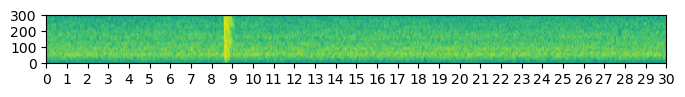

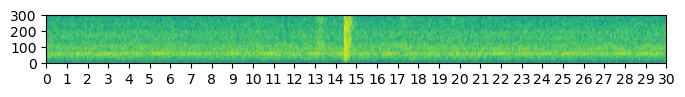

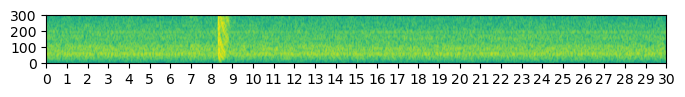

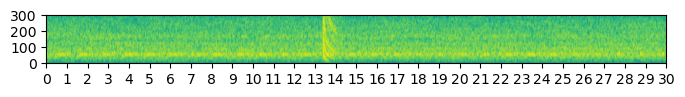

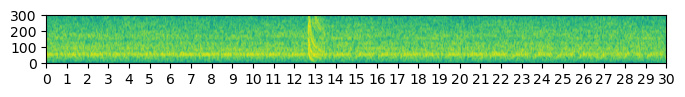

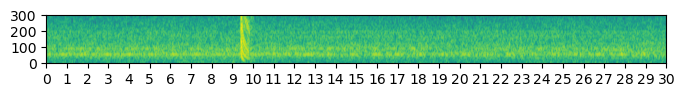

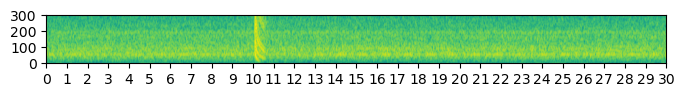

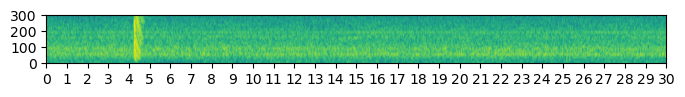

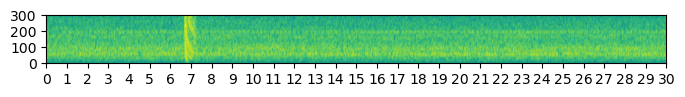

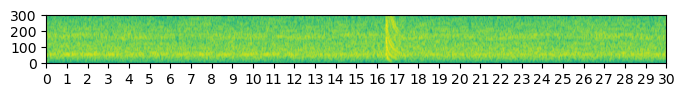

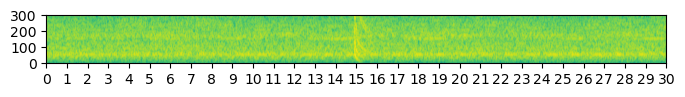

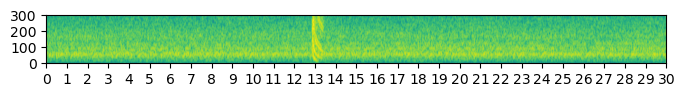

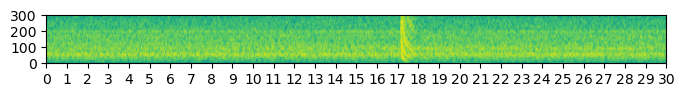

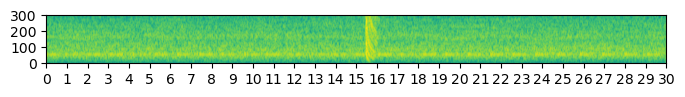

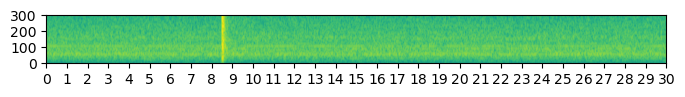

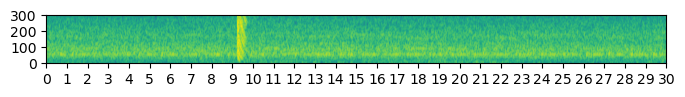

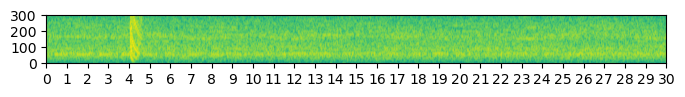

In [10]:
## Settings
chunk_size = 30
timestamp = '2022-05-24T03:56:40'

# object to read timestamp from WAV file
WR = WAVReader(sensors=config['TOSSIT']['ids'], chunk_size=chunk_size, fs_desired=config['signal']['fs'])

success, file_list, data, file_times = WR.get_audio(timestamp=np.datetime64(timestamp))
print(success)
print(data.shape)
print(file_list)
print(file_times)

for i in range(data.shape[0]):
    fig = plt.figure()
    ax2 = fig.gca()
    spect = to_spect(data[i,...] - data[i,...].mean()).squeeze()
    ax2.imshow(spect)

    # set x ticks
    x_tick_labels = np.arange(0, chunk_size + 1, 1)
    old_range_x = [0, chunk_size]
    new_range_x = [0, spect.shape[1]]
    ax2.set_xticks([convert_range(old_range_x, new_range_x, val) for val in x_tick_labels])
    ax2.set_xticklabels([int(val) if val.is_integer() else val for val in x_tick_labels])

    # set y ticks
    y_tick_labels = np.arange(0, config['signal']['fs'] / 2 + 1, 100)
    old_range_y = [0, config['signal']['fs'] / 2]
    new_range_y = [0, spect.shape[0]]
    ax2.set_yticks([convert_range(old_range_y, new_range_y, val) for val in y_tick_labels])
    ax2.set_yticklabels(reversed([int(val) if val.is_integer() else val for val in y_tick_labels]))

## Process Data

Preprocess Data

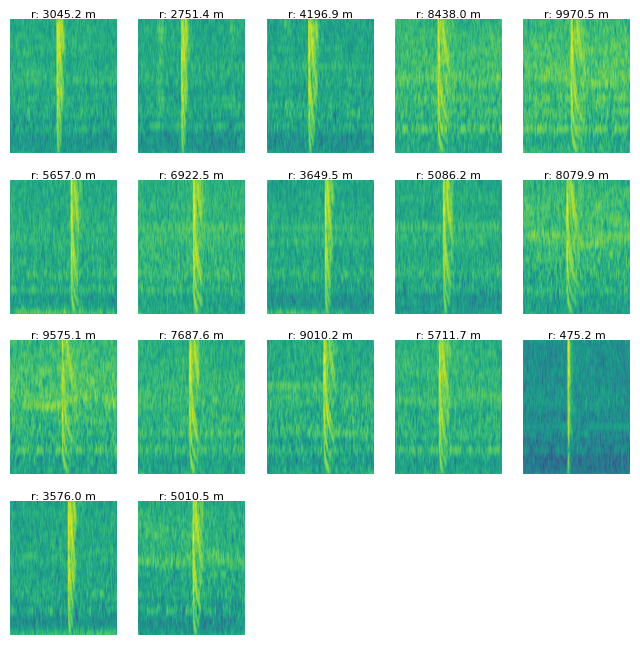

In [15]:
with h5py.File(os.path.join("/",ccb_data_root,"gunshots_55.h5"), "r") as f:
    inputs = f["/data"][:]
    sensors = f["/sensors"][:].squeeze()
    true_latlon = f["/location"][:].squeeze()
    
# get sensor indices
sensor_indices = sensor2idx(sensors)
    
# get position and sensor ranges
xt, yt = pargs(true_latlon[1], true_latlon[0])
yt = -yt
ranges = np.sqrt(((TOSSIT_locations - np.asarray([[yt, xt]])) ** 2).sum(axis=1))

# mean center + L2 norm
inputs = inputs - inputs.mean(axis=1, keepdims=True)
inputs = inputs / np.sqrt((inputs ** 2).sum(axis=1, keepdims=True))

# convert to spectrogram and preprocess
inputs = torch.from_numpy(to_spect(inputs).copy()).float()
inputs = transform(inputs).squeeze()

# display data
rows = int(np.floor(np.sqrt(inputs.shape[0])));
columns = int(np.ceil(inputs.shape[0]/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        if c >= inputs.shape[0]:
            fig.delaxes(ax2)
        else:
            ax2.imshow(inputs[c,...], aspect='auto')
            ax2.axis('off')
            ax2.set_title(f"r: {np.around(ranges[c], 1)} m",fontsize=8, y=0.95)
        c += 1

statistics
-------------------
MAE: 1017.905 m


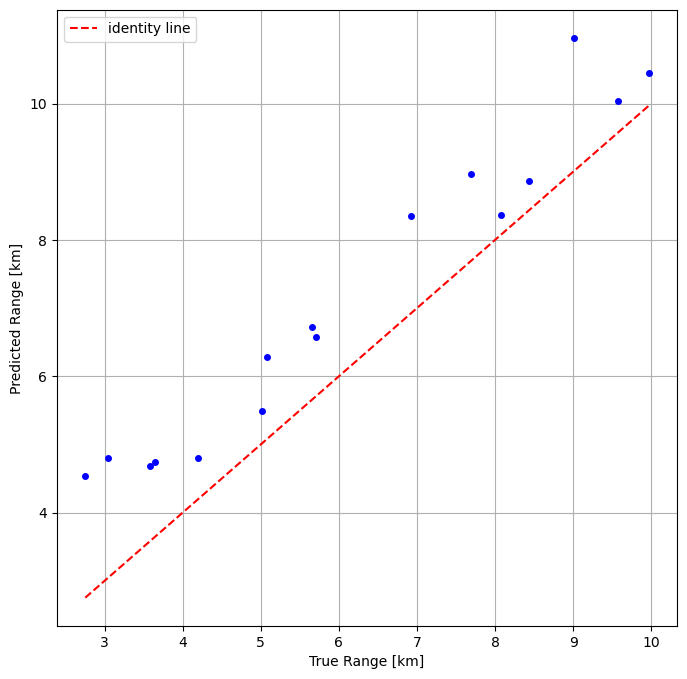

In [16]:
with torch.set_grad_enabled(False):
    inputs = inputs.to(device)
    outputs = model(inputs).to('cpu')

detections_idx = np.where(F.softmax(outputs[:,1:], dim=1)[:,1] >= 0.5)[0]

rp = (outputs[detections_idx,0] * config['scaling']['max_r']).numpy()

sensors_idx = np.asarray(sensor2idx(sensors[detections_idx]))

plot_range_regression(ranges[detections_idx], rp)
print("statistics")
print("-------------------")
print(f'MAE: {np.around(np.abs(rp - ranges[detections_idx]).mean(), 3)} m')

### Localization

In [17]:
loc = localize(rp, sensors_idx, TOSSIT_locations)

statistics
-------------------
Error: 1722.606 m


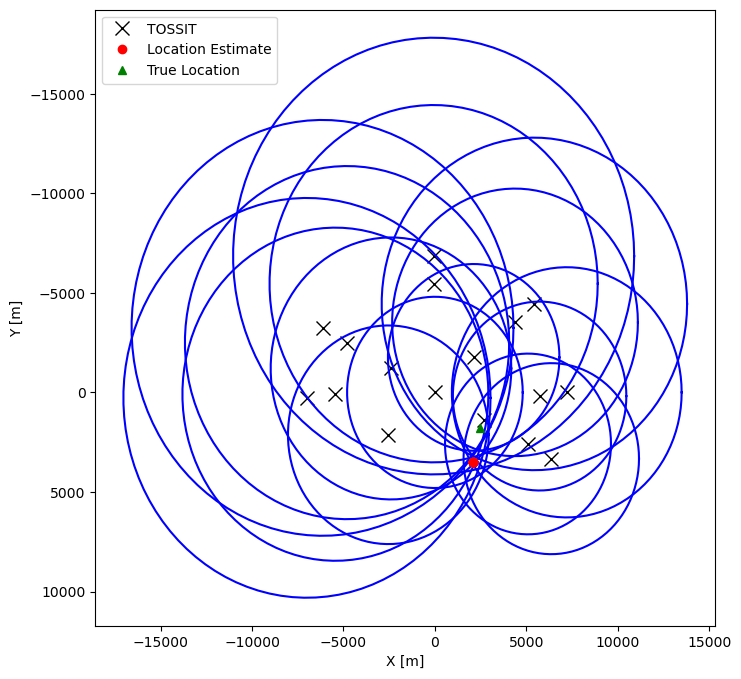

In [18]:
plot_localization(rp, np.asarray([yt, xt]), loc, sensors=sensors_idx, include_predictions=True, circles=True)

print("statistics")
print("-------------------")
print(f'Error: {np.around(np.sqrt(((loc - np.asarray([yt, xt])) ** 2).sum()), 3)} m')

### Scan and Localize

Get Data Scanner

In [19]:
data_params = {'fs' : config['signal']['fs'],
               'T' : config['signal']['T'],}
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))

CA = ClipAnalyzer(model, 
                  data_params, 
                  preprocessor,
                  device)
                  

Preprocess Data

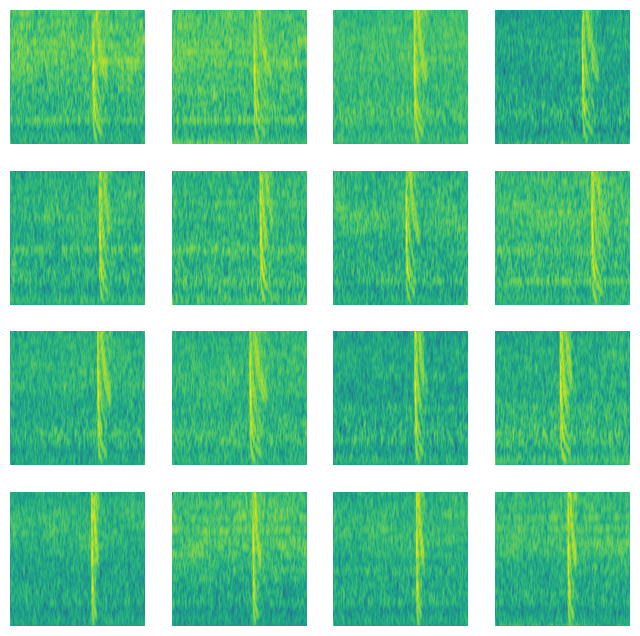

In [71]:
with h5py.File(os.path.join("/",ccb_data_root,"gunshots_long_50.h5"), "r") as f:
    inputs = f["/data"][:]
    sensors = f["/sensors"][:].squeeze()
    true_latlon = f["/location"][:].squeeze()
    
# get sensor indices
sensors_idx = sensor2idx(sensors)
    
# get position and sensor ranges
xt, yt = pargs(true_latlon[1], true_latlon[0])
yt = -yt
ranges = np.sqrt(((TOSSIT_locations - np.asarray([[yt, xt]])) ** 2).sum(axis=1))

result = CA.process_clips(inputs)

rp = [x[1] for x in result]
spects = [x[0].squeeze() for x in result if len(x[1])]
present = [i for i in range(len(result)) if len(result[i][1])]

rows = int(np.floor(np.sqrt(len(spects))));
columns = int(np.ceil(len(spects)/rows));
fig, axs = plt.subplots(rows,columns)
c = 0
for ax1 in axs:
    for ax2 in ax1:
        if c >= len(spects):
            fig.delaxes(ax2)
        else:
            ax2.imshow(spects[sensors_idx[c]].squeeze(), aspect='auto')
            ax2.axis('off')
            # ax2.set_title(f"r: {np.around(ranges[c], 1)} m",fontsize=8, y=0.95)
        c += 1

In [72]:
L = Localizer(k=6, multilat=MultilaterationOpt(method_thresh=float('inf')), consistency_thresh=1300, prune=False)

success = L.set_measurements(rp, adaptive=False)
assocs, loc = L.associate_and_localize(reduce_dups=False, last_step=True)

statistics
-------------------
Error: 77.649 m


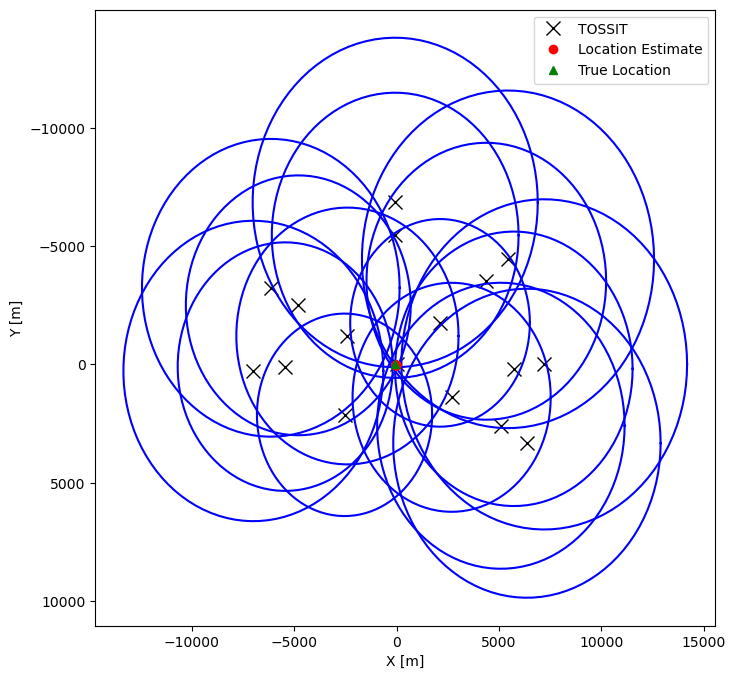

In [73]:
rp_linear = []
sensor_list = []
for idx,i in enumerate(rp):
    for j in i:
        rp_linear.append(j)
        sensor_list.append(idx)

plot_localization(rp_linear, np.asarray([yt, xt]), loc[0], sensors=sensor_list ,include_predictions=True, circles=True)
print("statistics")
print("-------------------")
print(f'Error: {np.around(np.sqrt(((loc - np.asarray([yt, xt])) ** 2).sum()), 3)} m')

In [81]:
m = -float('inf')
for i in range(TOSSIT_locations.shape[0]):
    mm = max(np.sqrt(((TOSSIT_locations - TOSSIT_locations[i,:]) ** 2).sum(axis=1)))
    if mm > m:
        m = mm
m

14209.999049585507